### STEP 1: Import all required libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud

###  Machine Learning libraries

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

### Dashboard libraries

In [5]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

### STEP 2: Load the dataset


In [6]:
df = pd.read_csv('flipkart_phones.csv')
print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")



Data loaded successfully!
Dataset shape: (960, 5)


### STEP 3: Initial data inspection

In [9]:
print("Step 3: Initial Data Inspection")
print("Column names:")
print(df.columns.tolist())
print("Missing values:")
print(df.isnull().sum())
print("First 5 rows:")
print(df.head())

Step 3: Initial Data Inspection
Column names:
['Product', 'Description', 'Review', 'Rating', 'Price']
Missing values:
Product        0
Description    0
Review         2
Rating         2
Price          1
dtype: int64
First 5 rows:
                                           Product  \
0             OnePlus 13R 5G (Nebula Noir, 512 GB)   
1      SAMSUNG Galaxy S24 FE 5G (Graphite, 256 GB)   
2  Motorola Edge 50 Ultra 5G (Nordic Wood, 512 GB)   
3                      Apple 13 (Midnight, 128 GB)   
4      SAMSUNG Galaxy S24 FE 5G (Graphite, 128 GB)   

                                         Description  \
0  16 GB RAM | 512 GB ROM17.22 cm (6.78 inch) Dis...   
1  8 GB RAM | 256 GB ROM17.02 cm (6.7 inch) Full ...   
2  12 GB RAM | 512 GB ROM17.02 cm (6.7 inch) Disp...   
3  128 GB ROM15.49 cm (6.1 inch) Super Retina XDR...   
4  8 GB RAM | 128 GB ROM17.02 cm (6.7 inch) Full ...   

                           Review  Rating    Price  
0        124 Ratings & 10 Reviews     4.5  ₹45,885  
1 

### STEP 4: Clean column names

In [10]:
df.columns = df.columns.str.strip().str.lower()
print("Step 4: Column names cleaned")


Step 4: Column names cleaned


### STEP 5: Clean price column (remove ₹ and commas)


In [11]:
df['price'] = df['price'].str.replace(r'[^\d]', '', regex=True).astype(float)
print("Step 5: Price column cleaned")


Step 5: Price column cleaned


### STEP 6: Convert rating to numeric

In [13]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
print(" Step 6: Rating converted to numeric")

 Step 6: Rating converted to numeric


### STEP 7: Extract numerical features from text columns

In [14]:
df['num_ratings'] = df['review'].str.extract(r'(\d+)\s*Ratings', flags=re.IGNORECASE)[0].astype(float)

# Extract number of reviews
df['num_reviews'] = df['review'].str.extract(r'(\d+)\s*Reviews', flags=re.IGNORECASE)[0].astype(float)

# Extract RAM
df['ram_gb'] = df['description'].str.extract(r'(\d+)\s*GB\s*RAM', flags=re.IGNORECASE)[0].astype(float)

# Extract Storage
df['storage_gb'] = df['description'].str.extract(r'(\d+)\s*GB\s*ROM', flags=re.IGNORECASE)[0].astype(float)

# Extract Display size
df['display_inch'] = df['description'].str.extract(r'(\d+\.\d+)\s*inch', flags=re.IGNORECASE)[0].astype(float)

# Extract Camera MP
df['camera_mp'] = df['description'].str.extract(r'(\d+)\s*MP\s*Rear', flags=re.IGNORECASE)[0].astype(float)

# Extract Battery capacity
df['battery_mah'] = df['description'].str.extract(r'(\d+)\s*mAh', flags=re.IGNORECASE)[0].astype(float)

# Extract Warranty
df['warranty_years'] = df['description'].str.extract(r'(\d+)\s*year', flags=re.IGNORECASE)[0].astype(float)



### STEP 8: Remove duplicate rows


In [15]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

### STEP 9: Handle missing values

In [16]:
df['price'] = df['price'].fillna(df['price'].median())
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['num_ratings'] = df['num_ratings'].fillna(0)
df['num_reviews'] = df['num_reviews'].fillna(0)
df['display_inch'] = df['display_inch'].fillna(df['display_inch'].median())
df['battery_mah'] = df['battery_mah'].fillna(df['battery_mah'].median())
df['warranty_years'] = df['warranty_years'].fillna(1.0)

# Fill categorical columns with mode
df['ram_gb'] = df['ram_gb'].fillna(df['ram_gb'].mode()[0])
df['storage_gb'] = df['storage_gb'].fillna(df['storage_gb'].mode()[0])
df['camera_mp'] = df['camera_mp'].fillna(df['camera_mp'].mode()[0])

In [19]:
print(f"Remaining missing values: {df.isnull().sum()}")

Remaining missing values: product           0
description       0
review            2
rating            0
price             0
num_ratings       0
num_reviews       0
ram_gb            0
storage_gb        0
display_inch      0
camera_mp         0
battery_mah       0
warranty_years    0
dtype: int64


### STEP 10: Save cleaned data

In [20]:
df.to_csv('flipkart_phones_cleaned.csv', index=False)

### STEP 11: Basic Data Exploration


In [21]:
print(f"Total phones in dataset: {len(df)}")
print(f"Average price: ₹{df['price'].mean():,.2f}")
print(f"Average rating: {df['rating'].mean():.2f}")
print(f"Number of unique brands: {df['product'].str.split().str[0].nunique()}")

Total phones in dataset: 792
Average price: ₹32,804.79
Average rating: 4.36
Number of unique brands: 31


### STEP 12: Create visualizations - Price Distribution

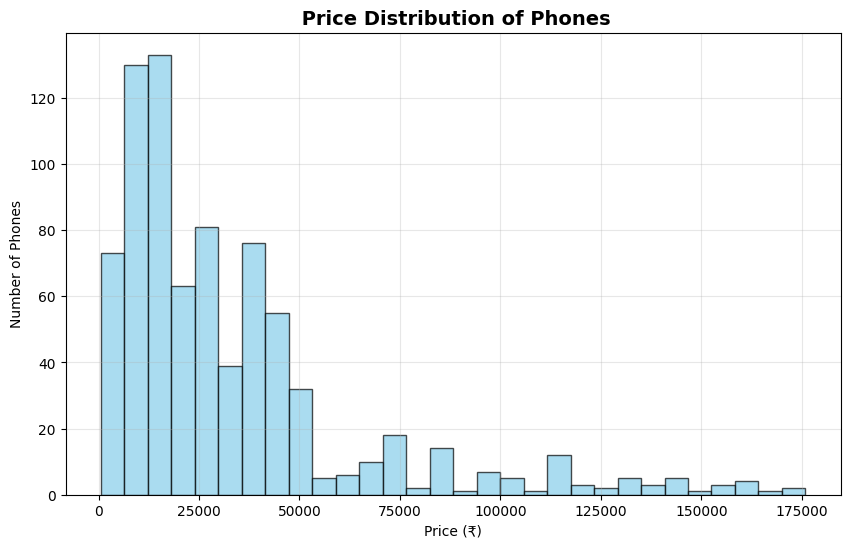

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(' Price Distribution of Phones', fontsize=14, fontweight='bold')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Phones')
plt.grid(True, alpha=0.3)
plt.show()

### STEP 13: Create visualizations - RAM Distribution

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


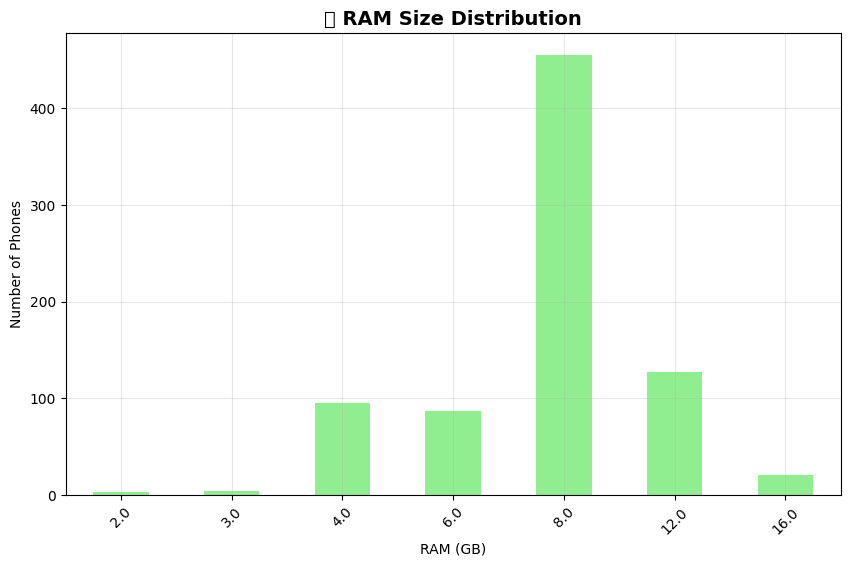

In [23]:
plt.figure(figsize=(10, 6))
df['ram_gb'].value_counts().sort_index().plot(kind='bar', color='lightgreen')
plt.title('💾 RAM Size Distribution', fontsize=14, fontweight='bold')
plt.xlabel('RAM (GB)')
plt.ylabel('Number of Phones')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### STEP 14: Create visualizations - Storage Distribution

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128189 (\N{MINIDISC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


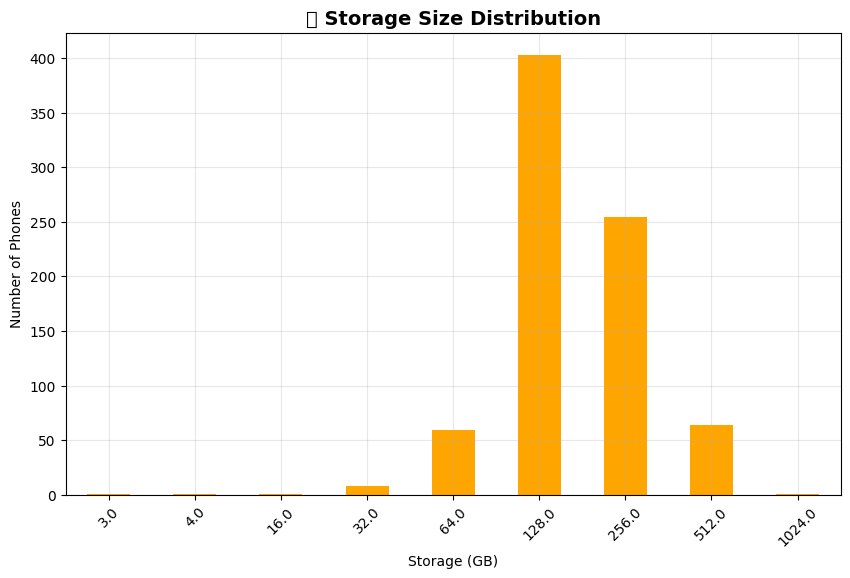

In [25]:
plt.figure(figsize=(10, 6))
df['storage_gb'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('💽 Storage Size Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Storage (GB)')
plt.ylabel('Number of Phones')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### STEP 15: Create correlation heatmap

/var/folders/kn/7p1wz_hj34z0jl07z3y80s700000gn/T/ipykernel_27280/2720563674.py:6: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


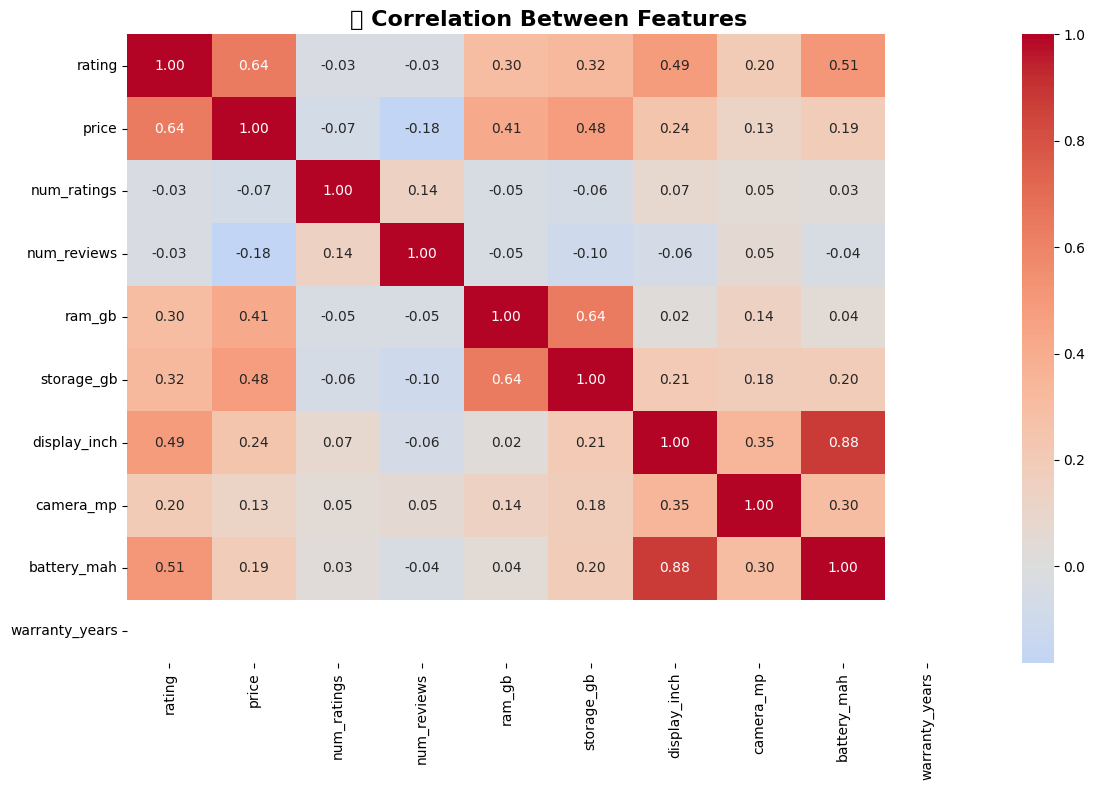

In [26]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('🔗 Correlation Between Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### STEP 16: Create word cloud from descriptions


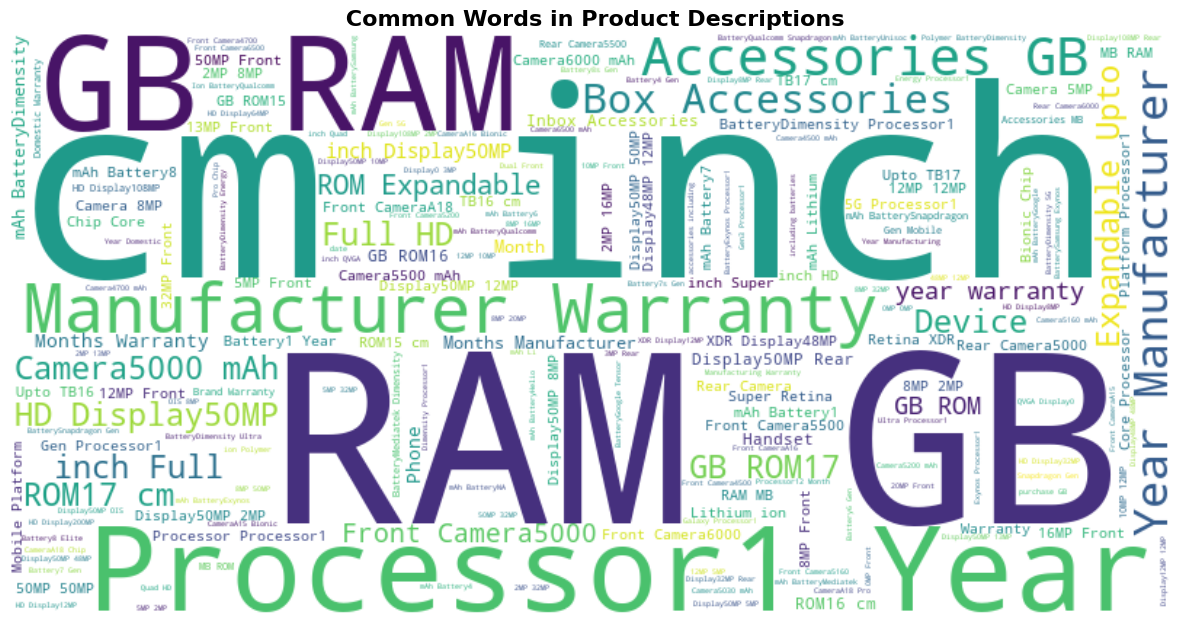

In [27]:
text = ' '.join(df['description'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Common Words in Product Descriptions', fontsize=16, fontweight='bold')
plt.show()

### STEP 17: Feature Engineering - Extract brand name

In [28]:
df['brand'] = df['product'].str.split().str[0]
print(f"Total brands: {df['brand'].nunique()}")

Total brands: 31


### STEP 18: Feature Engineering - Create price categories

In [29]:
df['price_category'] = pd.cut(df['price'], 
                             bins=[0, 10000, 20000, 50000, float('inf')],
                             labels=['Budget', 'Mid-Range', 'Premium', 'Flagship'])


### STEP 19: Filter data for budget phones (under ₹50,000)

In [30]:
budget_phones = df[df['price'] <= 50000].copy()

In [31]:
len(budget_phones)

682

### STEP 20: Prepare features for machine learning

In [32]:
features = ['ram_gb', 'storage_gb', 'display_inch', 'camera_mp', 'battery_mah', 'warranty_years', 'rating']
target = 'price'


In [33]:
X = budget_phones[features]
y = budget_phones[target]


### STEP 21: Encode brand names

In [34]:
label_encoder = LabelEncoder()
budget_phones['brand_encoded'] = label_encoder.fit_transform(budget_phones['brand'])
X['brand_encoded'] = budget_phones['brand_encoded']


/var/folders/kn/7p1wz_hj34z0jl07z3y80s700000gn/T/ipykernel_27280/1432414573.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['brand_encoded'] = budget_phones['brand_encoded']


### STEP 22: Split data into training and testing sets


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Training set: (545, 8)
Testing set: (137, 8)


### STEP 23: Train Linear Regression model

In [36]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions with Linear Regression
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics for Linear Regression
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

In [38]:
print(f"Mean Squared Error: {mse_linear:,.2f}")
print(f"R2 Score: {r2_linear:.4f}")


Mean Squared Error: 91,010,130.95
R2 Score: 0.5819


### STEP 24: Train Random Forest model

In [39]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions with Random Forest
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [40]:
print(f"Mean Squared Error: {mse_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Mean Squared Error: 26,566,260.49
R2 Score: 0.8780


### STEP 25: Feature importance analysis

In [42]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=True)

/var/folders/kn/7p1wz_hj34z0jl07z3y80s700000gn/T/ipykernel_27280/2418623944.py:5: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


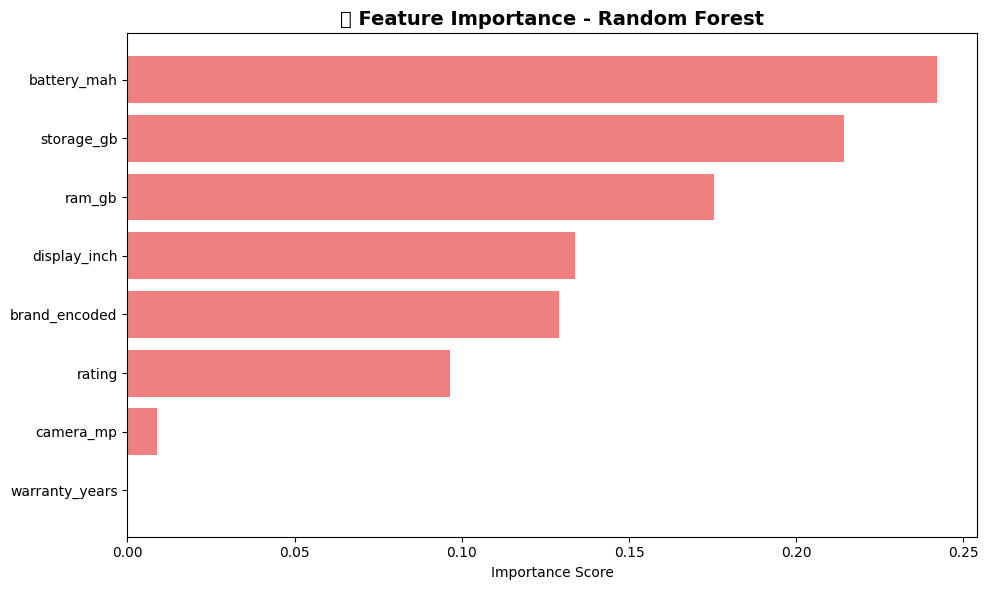

In [43]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightcoral')
plt.title('🔍 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [44]:
app = dash.Dash(__name__)

In [ ]:
app.title = "Flipkart Phone Analysis Dashboard"

# Define dashboard layout
app.layout = html.Div([
    html.H1("📱 Flipkart Mobile Phones Analysis Dashboard", 
            style={'textAlign': 'center', 'color': '#2C3E50', 'marginBottom': 30}),
    
    html.Div([
        dcc.Dropdown(
            id='brand-filter',
            options=[{'label': brand, 'value': brand} for brand in sorted(df['brand'].unique())],
            value=df['brand'].iloc[0],
            clearable=False,
            style={'width': '50%', 'margin': 'auto'}
        ),
    ], style={'marginBottom': 30}),
    
    html.Div([
        dcc.Graph(id='price-distribution'),
        dcc.Graph(id='specs-scatter')
    ], style={'display': 'flex', 'flexDirection': 'column', 'gap': '20px'})
])

# Define callback for interactive updates
@app.callback(
    [Output('price-distribution', 'figure'),
     Output('specs-scatter', 'figure')],
    [Input('brand-filter', 'value')]
)
def update_dashboard(selected_brand):
    # Filter data for selected brand
    filtered_df = df[df['brand'] == selected_brand]
    
    # Create price distribution chart
    price_fig = px.histogram(
        filtered_df, 
        x='price', 
        nbins=20,
        title=f'💰 Price Distribution - {selected_brand}',
        color_discrete_sequence=['#3498DB']
    )
    price_fig.update_layout(
        xaxis_title='Price (₹)',
        yaxis_title='Number of Models'
    )
    
    # Create specifications scatter plot
    specs_fig = px.scatter(
        filtered_df,
        x='ram_gb',
        y='price',
        size='storage_gb',
        color='rating',
        hover_name='product',
        title=f'⚙️ RAM vs Price - {selected_brand}',
        size_max=15
    )
    specs_fig.update_layout(
        xaxis_title='RAM (GB)',
        yaxis_title='Price (₹)'
    )
    
    return price_fig, specs_fig


In [47]:
app.run(debug=True)